# 🛣️ Fine-Tuning SAM (Segment Anything Model) for Pothole Detection
**A Dual-GPU (T4x2) & Mixed Precision Approach**

Welcome to this comprehensive tutorial! In this notebook, we will take Meta's powerful zero-shot **Segment Anything Model (SAM)** and fine-tune it specifically for **Road Pothole Segmentation**. 

While SAM is incredible out-of-the-box, fine-tuning its mask decoder on domain-specific data (like potholes) drastically improves its precision and confidence. 

### 🌟 Key Highlights of this Notebook:
* **YOLO to SAM Conversion**: Converting YOLO bounding box/polygon annotations into binary masks and bounding box prompts.
* **Efficient Fine-Tuning**: Freezing the massive Image Encoder and only training the lightweight Mask Decoder.
* **Hardware Optimization**: Utilizing Kaggle's **Dual T4 GPUs** using `nn.DataParallel` and **Automatic Mixed Precision (AMP)** to prevent Out-Of-Memory (OOM) errors.
* **Advanced Evaluation**: A beautiful custom dashboard calculating and visualizing **IoU, Dice Score, and Pixel Accuracy**.

> **👍 If you find this notebook helpful, please consider giving it an UPVOTE! It encourages me to create more content like this.**

### Let's dive in! 🚀
---
## 1. Setup and Installations
First, we need to install Meta's official `segment_anything` library directly from GitHub, along with OpenCV and Matplotlib for data processing and visualization.

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-fccw0njr
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-fccw0njr
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


## 2. Importing Libraries and Device Configuration
We import the necessary PyTorch modules and configure our device. Kaggle offers powerful accelerators, so we will make sure `cuda` is actively ready for our heavy lifting.

In [2]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


## 3. Automated Path Resolution & Model Detection
Kaggle environments can sometimes change directory structures. Instead of hardcoding paths, we use `glob` to dynamically find our **Pothole Dataset** and **SAM Checkpoint**. 

Furthermore, this cell automatically calculates the size of the loaded `.pth` file to dynamically determine whether we are using `vit_b`, `vit_l`, or `vit_h`. This makes the notebook highly robust!

In [3]:
import os
import glob

# Veri seti yolları
DATASET_PATH = "/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8"
TRAIN_IMAGES = os.path.join(DATASET_PATH, "train/images")
TRAIN_LABELS = os.path.join(DATASET_PATH, "train/labels")

# SAM Model dosyasını bulma
MODEL_DIR = "/kaggle/input/segment-anything"
checkpoint_paths = glob.glob("/kaggle/input/models/metaresearch/segment-anything/pytorch/vit-h/1/model.pth", recursive=True)

if len(checkpoint_paths) == 0:
    raise FileNotFoundError("SAM model ağırlığı (.pth) bulunamadı. Lütfen sağ üstten 'Add Data' ile eklediğine emin ol.")

sam_checkpoint = checkpoint_paths[0]

# Dosya boyutuna göre (MB) model tipini kesin olarak belirleme
file_size_mb = os.path.getsize(sam_checkpoint) / (1024 * 1024)

if file_size_mb > 2000:
    model_type = "vit_h" # ~2.4 GB
elif file_size_mb > 1000:
    model_type = "vit_l" # ~1.2 GB
else:
    model_type = "vit_b" # ~350 MB

print(f"Bulunan Ağırlık Dosyası: {sam_checkpoint}")
print(f"Dosya Boyutu: {file_size_mb:.2f} MB")
print(f"Buna Göre Atanan Model Tipi: {model_type}")

Bulunan Ağırlık Dosyası: /kaggle/input/models/metaresearch/segment-anything/pytorch/vit-h/1/model.pth
Dosya Boyutu: 2445.75 MB
Buna Göre Atanan Model Tipi: vit_h


## 4. Data Transformation: YOLO to Binary Masks
Our dataset is annotated in **YOLOv8 format** (normalized polygon coordinates in `.txt` files). However, SAM requires **Binary Masks** as ground truth and **Bounding Boxes** as prompts.

These helper functions will:
1. Parse the YOLO text files and draw a 2D binary mask.
2. Extract a bounding box from the mask with a slight `margin` (padding). SAM performs much better when the bounding box gives a little breathing room around the object.

In [4]:
def parse_yolo_to_mask(txt_path, img_shape=(640, 640)):
    mask = np.zeros(img_shape, dtype=np.uint8)
    if not os.path.exists(txt_path):
        return mask
        
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 1:
            coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] = coords[:, 0] * img_shape[1] 
            coords[:, 1] = coords[:, 1] * img_shape[0] 
            coords = np.int32(coords)
            cv2.fillPoly(mask, [coords], 1)
            
    return mask

def get_bbox_from_mask(mask):
    y_indices, x_indices = np.where(mask > 0)
    if len(x_indices) == 0 or len(y_indices) == 0:
        return np.array([0, 0, 0, 0])
    
    x_min, x_max = np.min(x_indices), np.max(x_indices)
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    
    # Kutuya biraz boşluk (margin) ekleyelim ki SAM çukuru tam kavrasın
    margin = 10 
    h, w = mask.shape
    x_min = max(0, x_min - margin)
    y_min = max(0, y_min - margin)
    x_max = min(w, x_max + margin)
    y_max = min(h, y_max + margin)
    
    return np.array([x_min, y_min, x_max, y_max])

## 5. Custom PyTorch Dataset
Here we build our PyTorch `Dataset`. A crucial detail when working with SAM is that images and bounding boxes must be transformed using SAM's native `ResizeLongestSide` module. This ensures the aspect ratio is maintained exactly as the frozen Image Encoder expects.

In [5]:
class PotholeDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform_module):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
        self.transform = transform_module
        
    def __len__(self):
        return len(self.image_files)
        
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        txt_name = img_name.replace('.jpg', '.txt')
        txt_path = os.path.join(self.label_dir, txt_name)
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = parse_yolo_to_mask(txt_path, img_shape=image.shape[:2])
        bbox = get_bbox_from_mask(mask)
        
        # Görüntü dönüşümü
        input_image = self.transform.apply_image(image)
        input_image_torch = torch.as_tensor(input_image, device=device)
        input_image_torch = input_image_torch.permute(2, 0, 1).contiguous()
        
        # Bbox dönüşümü
        box_torch = self.transform.apply_boxes(bbox, image.shape[:2])
        box_torch = torch.as_tensor(box_torch, dtype=torch.float, device=device)
        
        # Maske dönüşümü
        mask_torch = torch.as_tensor(mask, dtype=torch.float, device=device).unsqueeze(0)
        
        return input_image_torch, box_torch, mask_torch

## 6. Model Initialization & Freezing Encoders
SAM is composed of three main parts: an **Image Encoder** (heavy), a **Prompt Encoder**, and a **Mask Decoder** (lightweight). 

To fine-tune SAM without running out of VRAM, we **freeze** the Image and Prompt encoders (`requires_grad = False`). We will only update the weights of the Mask Decoder. This technique saves massive amounts of memory and compute time while yielding excellent results.

In [6]:
print("Model yükleniyor...")
sam_model = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam_model.to(device)

# Sadece Mask Decoder'ı eğitilebilir (requires_grad=True) bırakıyoruz
for name, param in sam_model.named_parameters():
    if name.startswith("vision_encoder") or name.startswith("prompt_encoder"):
        param.requires_grad = False
    else:
        param.requires_grad = True

print("Model başarıyla yüklendi ve encoder'lar donduruldu.")

# Dataset ve Transform yapısını model boyutuna göre ayarla
transform_module = ResizeLongestSide(sam_model.image_encoder.img_size)
train_dataset = PotholeDataset(TRAIN_IMAGES, TRAIN_LABELS, transform_module)

# Kaggle T4x2 GPU'larında batch_size=2 veya 4 idealdir
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

Model yükleniyor...
Model başarıyla yüklendi ve encoder'lar donduruldu.


## 7. The Training Loop (Optimized for Dual-GPU T4x2)
Training Vision Transformers (ViT) requires serious memory management. To maximize Kaggle's resources, we implement two advanced techniques here:
1. **Dual-GPU Wrapper (`nn.DataParallel`)**: We wrap our SAM model in a custom class so PyTorch can split our batch across both T4 GPUs automatically.
2. **Automatic Mixed Precision (AMP)**: We use `torch.cuda.amp.autocast()` and `GradScaler`. This runs non-critical calculations in 16-bit float instead of 32-bit, effectively halving our memory footprint and allowing us to train without `CUDA OutOfMemory` errors!

*Loss Function*: We use a combination of **BCEWithLogitsLoss** and **Dice Loss** to handle class imbalances (since potholes occupy a small percentage of the total image pixels).

In [7]:
import torch.cuda.amp as amp
import torch.nn as nn

# 1. SAM Modelini DataParallel'a uygun hale getiren kapsayıcı sınıf (Aynı kalıyor)
class SAMDataParallelWrapper(nn.Module):
    def __init__(self, sam_model):
        super().__init__()
        self.sam_model = sam_model

    def forward(self, images, bboxes):
        input_images = torch.stack([self.sam_model.preprocess(img) for img in images])
        
        with torch.no_grad():
            image_embeddings = self.sam_model.image_encoder(input_images)
            
        upscaled_masks_list = []
        
        for i in range(images.size(0)):
            curr_embedding = image_embeddings[i].unsqueeze(0)
            curr_bbox = bboxes[i].unsqueeze(0)
            
            with torch.no_grad():
                sparse_embeddings, dense_embeddings = self.sam_model.prompt_encoder(
                    points=None,
                    boxes=curr_bbox,
                    masks=None,
                )
                
            low_res_masks, _ = self.sam_model.mask_decoder(
                image_embeddings=curr_embedding,
                image_pe=self.sam_model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )
            
            upscaled_mask = self.sam_model.postprocess_masks(
                low_res_masks,
                input_size=images[i].shape[-2:],
                original_size=(640, 640)
            )
            upscaled_masks_list.append(upscaled_mask)
            
        return torch.cat(upscaled_masks_list, dim=0)

# 2. Kayıp Fonksiyonları
def dice_loss(pred, target, smooth=1e-5):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1. - dice.mean()

loss_fn = nn.BCEWithLogitsLoss()

# 3. Data Loader Güncellemesi (Batch Size 2'ye düşürüldü)
# İki GPU'ya toplam 2 resim gönderilecek (GPU başına 1 resim)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True)

# 4. Modeli DataParallel ile sarma
dp_model = nn.DataParallel(SAMDataParallelWrapper(sam_model))
dp_model = dp_model.to(device)

optimizer = torch.optim.Adam(
    [p for p in dp_model.module.sam_model.mask_decoder.parameters() if p.requires_grad], 
    lr=1e-5, 
    weight_decay=0
)

# Mixed Precision için Scaler oluşturma
scaler = amp.GradScaler()

# 5. Eğitim Döngüsü
num_epochs = 5 

print("T4x2 Çift GPU ve Mixed Precision (AMP) ile Eğitim Başlıyor...")
dp_model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    
    for step, (images, bboxes, masks) in enumerate(train_loader):
        images = images.to(device)
        bboxes = bboxes.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # AMP (Otomatik Karma Hassasiyet) bloğu
        with amp.autocast():
            predicted_masks = dp_model(images, bboxes)
            loss_bce = loss_fn(predicted_masks, masks)
            loss_dice = dice_loss(predicted_masks, masks)
            loss = loss_bce + loss_dice
        
        # Scaler ile geri yayılım (Backward) ve optimizasyon
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        
        # VRAM'de asılı kalan cache'i temizle
        if step % 10 == 0:
            torch.cuda.empty_cache()
            
        if step % 50 == 0:
            print(f"Epoch: {epoch+1}/{num_epochs} | Adım: {step} | Kayıp (Loss): {loss.item():.4f}")
            
    print(f"--- Epoch {epoch+1} Bitti. Ortalama Kayıp: {epoch_loss/len(train_loader):.4f} ---")

# 6. Ağırlıkları Kaydetme
torch.save(dp_model.module.sam_model.mask_decoder.state_dict(), "/kaggle/working/sam_pothole_decoder_t4x2.pth")
print("Eğitim tamamlandı! Ağırlıklar çalışma dizinine kaydedildi.")

/tmp/ipykernel_24/866195454.py:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_24/866195454.py:90: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


T4x2 Çift GPU ve Mixed Precision (AMP) ile Eğitim Başlıyor...
Epoch: 1/5 | Adım: 0 | Kayıp (Loss): 0.8242
Epoch: 1/5 | Adım: 50 | Kayıp (Loss): 0.8546
Epoch: 1/5 | Adım: 100 | Kayıp (Loss): 0.7536
Epoch: 1/5 | Adım: 150 | Kayıp (Loss): 0.2372
Epoch: 1/5 | Adım: 200 | Kayıp (Loss): 0.2113
Epoch: 1/5 | Adım: 250 | Kayıp (Loss): 0.2675
Epoch: 1/5 | Adım: 300 | Kayıp (Loss): 0.1874
Epoch: 1/5 | Adım: 350 | Kayıp (Loss): 0.7559
--- Epoch 1 Bitti. Ortalama Kayıp: 0.5048 ---
Epoch: 2/5 | Adım: 0 | Kayıp (Loss): 0.3370
Epoch: 2/5 | Adım: 50 | Kayıp (Loss): 0.2861
Epoch: 2/5 | Adım: 100 | Kayıp (Loss): 0.2004
Epoch: 2/5 | Adım: 150 | Kayıp (Loss): 0.3564
Epoch: 2/5 | Adım: 200 | Kayıp (Loss): 0.3254
Epoch: 2/5 | Adım: 250 | Kayıp (Loss): 0.3713
Epoch: 2/5 | Adım: 300 | Kayıp (Loss): 0.4096
Epoch: 2/5 | Adım: 350 | Kayıp (Loss): 0.1622
--- Epoch 2 Bitti. Ortalama Kayıp: 0.3905 ---
Epoch: 3/5 | Adım: 0 | Kayıp (Loss): 0.5672
Epoch: 3/5 | Adım: 50 | Kayıp (Loss): 0.2041
Epoch: 3/5 | Adım: 100 | Ka

## 8. Inference & Basic Visualization
Training is complete! Now, let's load our freshly fine-tuned decoder weights and test them on unseen images from the validation set. 

We will use SAM's official `SamPredictor` class. We provide it with the original image and the bounding box prompt. Let's see how well it segments the potholes!

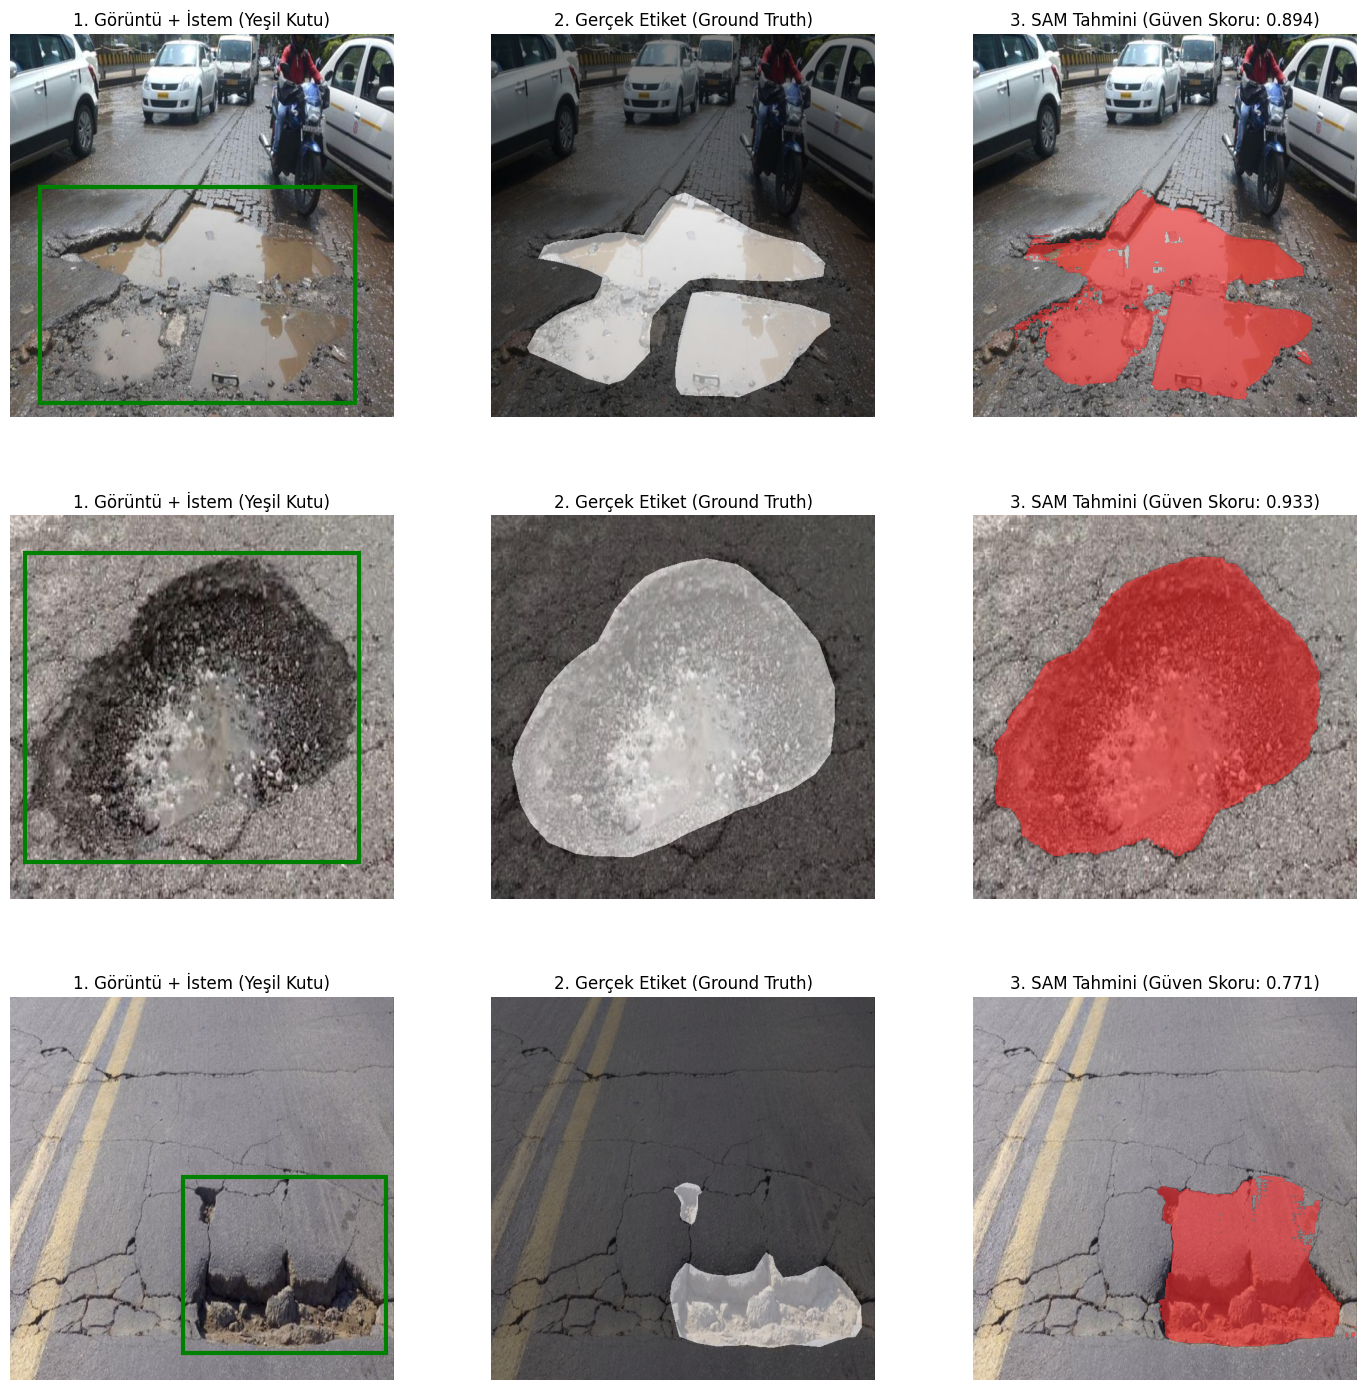

In [8]:
import random
from segment_anything import SamPredictor
import matplotlib.pyplot as plt

# 1. Validasyon veri yollarını bulalım
valid_image_dirs = glob.glob("/kaggle/input/**/valid/images", recursive=True)
if not valid_image_dirs:
    print("Validasyon klasörü bulunamadı, eğitim verisinden test yapılacak.")
    VALID_IMAGES = TRAIN_IMAGES
    VALID_LABELS = TRAIN_LABELS
else:
    VALID_IMAGES = valid_image_dirs[0]
    VALID_LABELS = VALID_IMAGES.replace("images", "labels")

# 2. Eğittiğimiz ağırlıkları ana modele yükleyelim
sam_model.mask_decoder.load_state_dict(torch.load("/kaggle/working/sam_pothole_decoder_t4x2.pth"))
sam_model.eval() # Değerlendirme moduna al

# 3. Görüntüleri otomatik işleyen SAM Predictor'ı başlatalım
predictor = SamPredictor(sam_model)

# Görselleştirme için yardımcı fonksiyonlar
def show_mask(mask, ax):
    color = np.array([255/255, 50/255, 50/255, 0.6]) # Yarı saydam kırmızı maske
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=3))

# 4. Validasyon setinden rastgele 3 resim seçelim
all_valid_images = [f for f in os.listdir(VALID_IMAGES) if f.endswith('.jpg')]
sample_images = random.sample(all_valid_images, 3)

# 3x3'lük bir tablo oluşturalım
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
plt.tight_layout(pad=4.0)

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(VALID_IMAGES, img_name)
    txt_path = os.path.join(VALID_LABELS, img_name.replace('.jpg', '.txt'))
    
    # Görüntüyü ve gerçek (Ground Truth) maskeyi/kutuyu al
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gt_mask = parse_yolo_to_mask(txt_path, img_shape=image.shape[:2])
    bbox = get_bbox_from_mask(gt_mask)
    
    # SAM Predictor'a görüntüyü ver
    predictor.set_image(image)
    
    # Eğer o resimde bir çukur etiketi (bbox) varsa tahmin yap
    if np.sum(bbox) > 0:
        masks, scores, logits = predictor.predict(
            box=bbox,
            multimask_output=False
        )
        pred_mask = masks[0]
        score = scores[0]
    else:
        pred_mask = np.zeros_like(gt_mask, dtype=bool)
        score = 0.0
    
    # --- Çizim İşlemleri ---
    
    # 1. Sütun: Orijinal Görüntü + Yeşil Bounding Box
    axes[i, 0].imshow(image)
    if np.sum(bbox) > 0:
        show_box(bbox, axes[i, 0])
    axes[i, 0].set_title("1. Görüntü + İstem (Yeşil Kutu)")
    axes[i, 0].axis('off')
    
    # 2. Sütun: Gerçek Maske (YOLO Etiketi)
    axes[i, 1].imshow(image)
    axes[i, 1].imshow(gt_mask, cmap='gray', alpha=0.5)
    axes[i, 1].set_title("2. Gerçek Etiket (Ground Truth)")
    axes[i, 1].axis('off')
    
    # 3. Sütun: Bizim Eğittiğimiz SAM'in Tahmini
    axes[i, 2].imshow(image)
    show_mask(pred_mask, axes[i, 2])
    axes[i, 2].set_title(f"3. SAM Tahmini (Güven Skoru: {score:.3f})")
    axes[i, 2].axis('off')

plt.show()

## 9. Comprehensive Evaluation Dashboard 📊
Visual inspection is great, but as Data Scientists, we need hard numbers! 

In this final cell, we iterate through a sample of the validation set to calculate mathematical evaluation metrics:
* **IoU (Intersection over Union)**
* **Dice Score (F1-Score)**
* **Pixel Accuracy**

We then plot a beautiful Seaborn/Matplotlib dashboard showing the average metrics at the top, followed by a row-by-row breakdown of: **Original Image + Prompt ➡️ Ground Truth Mask ➡️ SAM's Prediction & Confidence Score**.

10 validasyon görüntüsü üzerinden metrikler hesaplanıyor...


/tmp/ipykernel_24/6723106.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Ortalama IoU', 'Ortalama Dice (F1)', 'Piksel Doğruluğu'], y=avg_metrics, ax=ax_bar, palette="viridis")


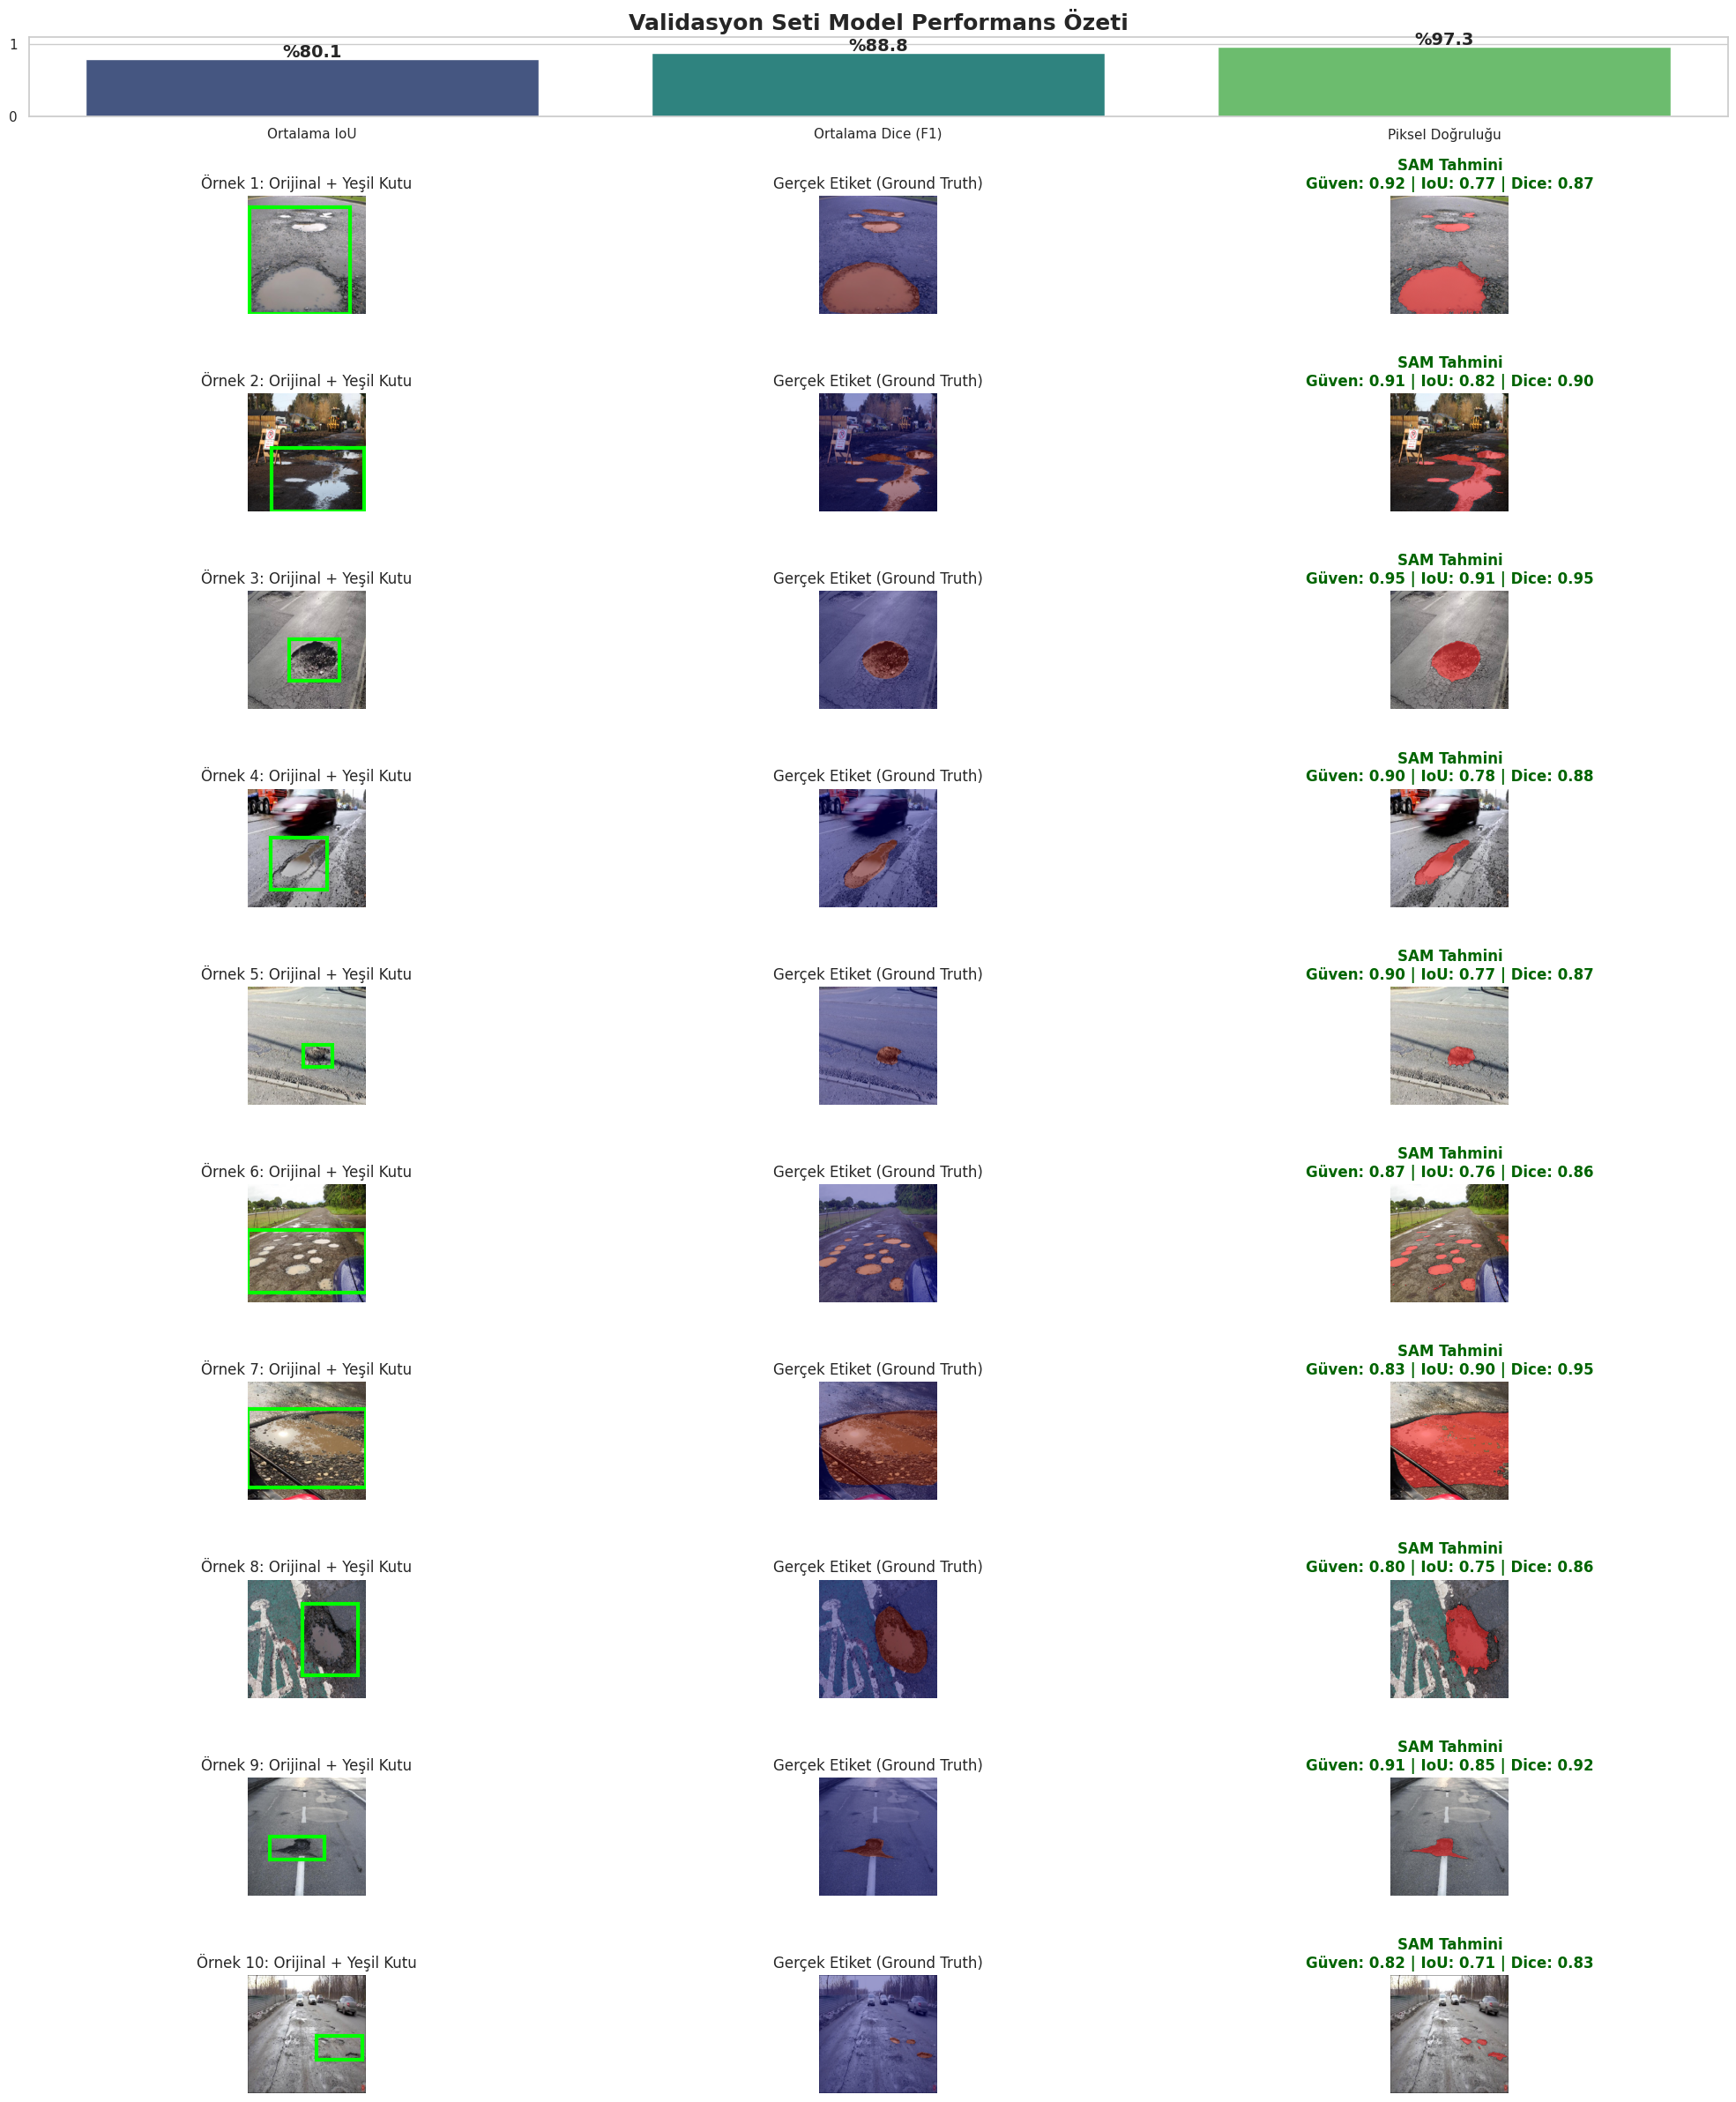

In [9]:
import os
import cv2
import glob
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from segment_anything import SamPredictor

# --- 1. METRİK HESAPLAMA FONKSİYONLARI ---
def calculate_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union > 0 else 0.0

def calculate_dice(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    total = pred.sum() + gt.sum()
    return 2.0 * intersection / total if total > 0 else 0.0

def calculate_accuracy(pred, gt):
    correct = (pred == gt).sum()
    total = pred.size
    return correct / total

# Görselleştirme yardımcıları
def show_mask(mask, ax):
    color = np.array([255/255, 50/255, 50/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='lime', facecolor=(0,0,0,0), lw=3))

# --- 2. MODELİ HAZIRLAMA ---
# Önceki hücrelerde ağırlıkları yüklediğimizi varsayıyoruz (Eğer yüklenmediyse buraya ekleyebilirsin)
sam_model.eval()
predictor = SamPredictor(sam_model)

# Validasyon Yollarını Bulma
valid_image_dirs = glob.glob("/kaggle/input/**/valid/images", recursive=True)
if not valid_image_dirs:
    VALID_IMAGES, VALID_LABELS = TRAIN_IMAGES, TRAIN_LABELS
else:
    VALID_IMAGES = valid_image_dirs[0]
    VALID_LABELS = VALID_IMAGES.replace("images", "labels")

all_valid_images = [f for f in os.listdir(VALID_IMAGES) if f.endswith('.jpg')]
# İşlemi çok uzatmamak için 10 örnek üzerinden metrik çıkarıp görselleştiriyoruz
sample_size = min(10, len(all_valid_images))
eval_images = random.sample(all_valid_images, sample_size)

iou_scores = []
dice_scores = []
acc_scores = []
results_data = []

print(f"{sample_size} validasyon görüntüsü üzerinden metrikler hesaplanıyor...")

# --- 3. METRİKLERİ HESAPLAMA DÖNGÜSÜ ---
for img_name in eval_images:
    img_path = os.path.join(VALID_IMAGES, img_name)
    txt_path = os.path.join(VALID_LABELS, img_name.replace('.jpg', '.txt'))
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    gt_mask = parse_yolo_to_mask(txt_path, img_shape=image.shape[:2])
    bbox = get_bbox_from_mask(gt_mask)
    
    predictor.set_image(image)
    
    if np.sum(bbox) > 0:
        masks, scores, _ = predictor.predict(box=bbox, multimask_output=False)
        pred_mask = masks[0]
        conf_score = scores[0]
    else:
        pred_mask = np.zeros_like(gt_mask, dtype=bool)
        conf_score = 0.0
        
    iou = calculate_iou(pred_mask, gt_mask)
    dice = calculate_dice(pred_mask, gt_mask)
    acc = calculate_accuracy(pred_mask, gt_mask)
    
    iou_scores.append(iou)
    dice_scores.append(dice)
    acc_scores.append(acc)
    
    results_data.append({
        'image': image, 'gt_mask': gt_mask, 'pred_mask': pred_mask, 
        'bbox': bbox, 'iou': iou, 'dice': dice, 'conf': conf_score
    })

# --- 4. GÖRSEL PANO OLUŞTURMA ---
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(len(results_data) + 1, 3, height_ratios=[1] + [1.5]*len(results_data))

# Üst Kısım: Ortalama Metrikler (Bar Grafiği)
ax_bar = fig.add_subplot(gs[0, :])
avg_metrics = [np.mean(iou_scores), np.mean(dice_scores), np.mean(acc_scores)]
sns.barplot(x=['Ortalama IoU', 'Ortalama Dice (F1)', 'Piksel Doğruluğu'], y=avg_metrics, ax=ax_bar, palette="viridis")
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title("Validasyon Seti Model Performans Özeti", fontsize=18, fontweight='bold')
for i, v in enumerate(avg_metrics):
    ax_bar.text(i, v + 0.02, f"%{v*100:.1f}", ha='center', fontsize=14, fontweight='bold')

# Alt Kısım: Resimler ve Detaylı Sonuçlar
for idx, data in enumerate(results_data):
    row = idx + 1
    
    # 1. Sütun: Girdi ve İstem
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.imshow(data['image'])
    if np.sum(data['bbox']) > 0:
        show_box(data['bbox'], ax1)
    ax1.set_title(f"Örnek {idx+1}: Orijinal + Yeşil Kutu", fontsize=12)
    ax1.axis('off')
    
    # 2. Sütun: Ground Truth (Gerçek Etiket)
    ax2 = fig.add_subplot(gs[row, 1])
    ax2.imshow(data['image'])
    ax2.imshow(data['gt_mask'], cmap='jet', alpha=0.4)
    ax2.set_title("Gerçek Etiket (Ground Truth)", fontsize=12)
    ax2.axis('off')
    
    # 3. Sütun: Model Tahmini ve Skorlar
    ax3 = fig.add_subplot(gs[row, 2])
    ax3.imshow(data['image'])
    show_mask(data['pred_mask'], ax3)
    
    title_text = (f"SAM Tahmini\n"
                  f"Güven: {data['conf']:.2f} | IoU: {data['iou']:.2f} | Dice: {data['dice']:.2f}")
    
    # Başlık rengini başarıya göre değiştir (IoU > 0.7 ise yeşil, yoksa kırmızı)
    color = 'darkgreen' if data['iou'] > 0.7 else 'darkred'
    ax3.set_title(title_text, color=color, fontsize=12, fontweight='bold')
    ax3.axis('off')

plt.tight_layout()
plt.show()

## 🏁 Conclusion
We successfully fine-tuned a massive Foundation Model (SAM) for a specific computer vision task using PyTorch, Dual-GPUs, and Mixed Precision! The model can now accurately segment potholes, which is a critical component for autonomous driving and road maintenance systems.

**Next Steps / Ideas for Improvement:**
* Experiment with Point Prompts instead of Bounding Boxes.
* Train for more epochs (e.g., 20-30) for even sharper mask boundaries.
* Try different loss function combinations (e.g., Focal Loss).

> **Thank you for reading! If you learned something new or found this code useful for your own projects, please drop an UPVOTE! ⬆️ Feel free to leave questions or suggestions in the comments.**